# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import os
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "README.md").is_file() and (p / "notebooks").is_dir()
    ),
    Path.cwd(),
)

configured_path = (
    Path(os.environ["CARDIO_DATA_PATH"]) if os.getenv("CARDIO_DATA_PATH") else None
)

if configured_path is not None and not configured_path.is_absolute():
    configured_path = ROOT / configured_path
candidates = [
    configured_path,
    ROOT / "data" / "raw" / "cardiovascular-disease.csv",
    ROOT / "data" / "raw" / "cardio_train.csv",
]

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
DATA_PATH = next((p for p in candidates if p is not None and p.is_file()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Letakkan CSV di data/raw/ atau set CARDIO_DATA_PATH."
    )

df = pd.read_csv(DATA_PATH, sep=";")

if df.shape[1] == 1 and "," in str(df.columns[0]):
    df = pd.read_csv(DATA_PATH)

print(f"File: {DATA_PATH}")
print(f"Data Size: {df.shape[0]:,} row x {df.shape[1]} column")
display(df.head())

File: /home/kuro/workspace/personal/cardiovascular-disease-mlops/data/raw/cardiovascular-disease.csv
Data Size: 70,000 row x 13 column


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
df.info()
display(df.isna().sum().rename("missing").to_frame())

print(f"Duplicate: {df.duplicated().sum():,}")

if "cardio" in df.columns:
    display(df["cardio"].value_counts(dropna=False).rename("count").to_frame())
    display(
        df["cardio"]
        .value_counts(normalize=True, dropna=False)
        .rename("proportion")
        .to_frame()
    )

display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,missing
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


Duplicate: 0


,count
cardio,
0,35021
1,34979


,proportion
cardio,
0,0.5003
1,0.4997


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [6]:
cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

print(df[cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T)

          count          mean          std      min       1%       5%  \
age     70000.0  19468.865814  2467.251667  10798.0  14466.0  15069.0   
height  70000.0    164.359229     8.210126     55.0    147.0    152.0   
weight  70000.0     74.205690    14.395757     10.0     48.0     55.0   
ap_hi   70000.0    128.817286   154.011419   -150.0     90.0    100.0   
ap_lo   70000.0     96.630414   188.472530    -70.0     60.0     70.0   

            50%      95%      99%      max  
age     19703.0  23259.0  23489.0  23713.0  
height    165.0    178.0    184.0    250.0  
weight     72.0    100.0    117.0    200.0  
ap_hi     120.0    160.0    180.0  16020.0  
ap_lo      80.0    100.0   1000.0  11000.0  


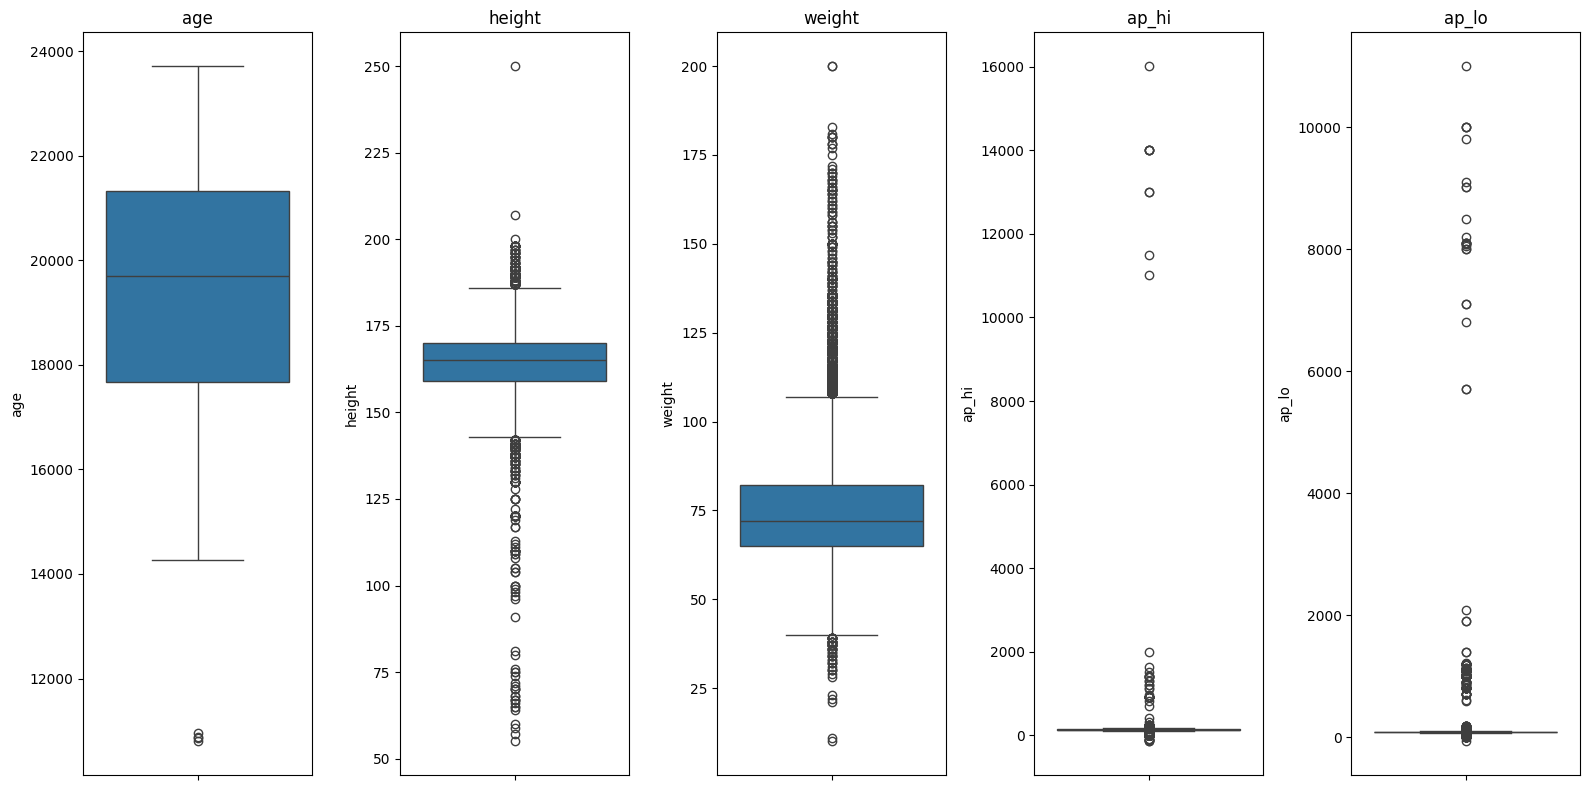

In [7]:
fig, axes = plt.subplots(1, len(cols), figsize=(16, 8))

for ax, c in zip(axes, cols):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)

plt.tight_layout()
figure_dir = ROOT / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(
    figure_dir / "boxplot_outlier_awal.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [8]:
def iqr_outliers(s, k=1.5):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - k * IQR, Q3 + k * IQR
    return (s < low) | (s > high), low, high


for c in cols:
    mask, low, high = iqr_outliers(df[c])
    print(
        f"{c}: {mask.sum()} outlier ({mask.mean():.2%}), batas [{low:.1f}, {high:.1f}]"
    )

age: 4 outlier (0.01%), batas [12169.5, 26821.5]
height: 519 outlier (0.74%), batas [142.5, 186.5]
weight: 1819 outlier (2.60%), batas [39.5, 107.5]
ap_hi: 1435 outlier (2.05%), batas [90.0, 170.0]
ap_lo: 4632 outlier (6.62%), batas [65.0, 105.0]


In [9]:
df_eda = df.assign(age_years=df["age"] / 365.25)

duplicate_without_id = df.drop(columns=["id"]).duplicated().sum()

predictor_columns = [column for column in df.columns if column not in {"id", "cardio"}]

conflicting_target_groups = (
    df.groupby(predictor_columns, dropna=False)["cardio"].nunique().gt(1).sum()
)

print(f"Duplikasi dengan id dikecualikan: {duplicate_without_id}")
print("Feature identik dengan target beda:", f"{conflicting_target_groups}")

Duplikasi dengan id dikecualikan: 24
Feature identik dengan target beda: 17


In [10]:
expected_categories = {
    "gender": {1, 2},
    "cholesterol": {1, 2, 3},
    "gluc": {1, 2, 3},
    "smoke": {0, 1},
    "alco": {0, 1},
    "active": {0, 1},
    "cardio": {0, 1},
}

for column, expected in expected_categories.items():
    observed = set(df[column].dropna().unique())
    unexpected = observed - expected
    print(
        f"{column}: Nilai Observed={sorted(observed)}, "
        f"Nilai diluar kode={sorted(unexpected)}"
    )

gender: Nilai Observed=[np.int64(1), np.int64(2)], Nilai diluar kode=[]
cholesterol: Nilai Observed=[np.int64(1), np.int64(2), np.int64(3)], Nilai diluar kode=[]
gluc: Nilai Observed=[np.int64(1), np.int64(2), np.int64(3)], Nilai diluar kode=[]
smoke: Nilai Observed=[np.int64(0), np.int64(1)], Nilai diluar kode=[]
alco: Nilai Observed=[np.int64(0), np.int64(1)], Nilai diluar kode=[]
active: Nilai Observed=[np.int64(0), np.int64(1)], Nilai diluar kode=[]
cardio: Nilai Observed=[np.int64(0), np.int64(1)], Nilai diluar kode=[]


In [11]:
qualitY_counts = pd.Series(
    {
        "ap_hi <= 0": (df["ap_hi"] <= 0).sum(),
        "ap_lo <= 0": (df["ap_lo"] <= 0).sum(),
        "ap_hi < ap_lo": (df["ap_hi"] < df["ap_lo"]).sum(),
        "height <= 0": (df["height"] <= 0).sum(),
        "weight <= 0": (df["weight"] <= 0).sum(),
    },
    name="row_count",
)

print("\nNilai tidak valid")
display(qualitY_counts.to_frame())


Nilai tidak valid


,row_count
ap_hi <= 0,7
ap_lo <= 0,22
ap_hi < ap_lo,1234
height <= 0,0
weight <= 0,0


In [13]:
continuous_columns = ["age_years", "height", "weight", "ap_hi", "ap_lo"]
outlier_rows = []

for column in continuous_columns:
    Q1 = df_eda[column].quantile(0.25)
    Q3 = df_eda[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    flagged = (df_eda[column] < lower_bound) | (df_eda[column] > upper_bound)

    outlier_rows.append(
        {
            "feature": column,
            "IQR_lower": lower_bound,
            "IQR_upper": upper_bound,
            "flagged_rows": int(flagged.sum()),
            "flagged_percent": 100 * flagged.mean(),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).set_index("feature")
display(outlier_summary.round(2))

,IQR_lower,IQR_upper,flagged_rows,flagged_percent
feature,,,,
age_years,33.32,73.43,4,0.01
height,142.50,186.50,519,0.74
weight,39.50,107.50,1819,2.60
ap_hi,90.00,170.00,1435,2.05
ap_lo,65.00,105.00,4632,6.62


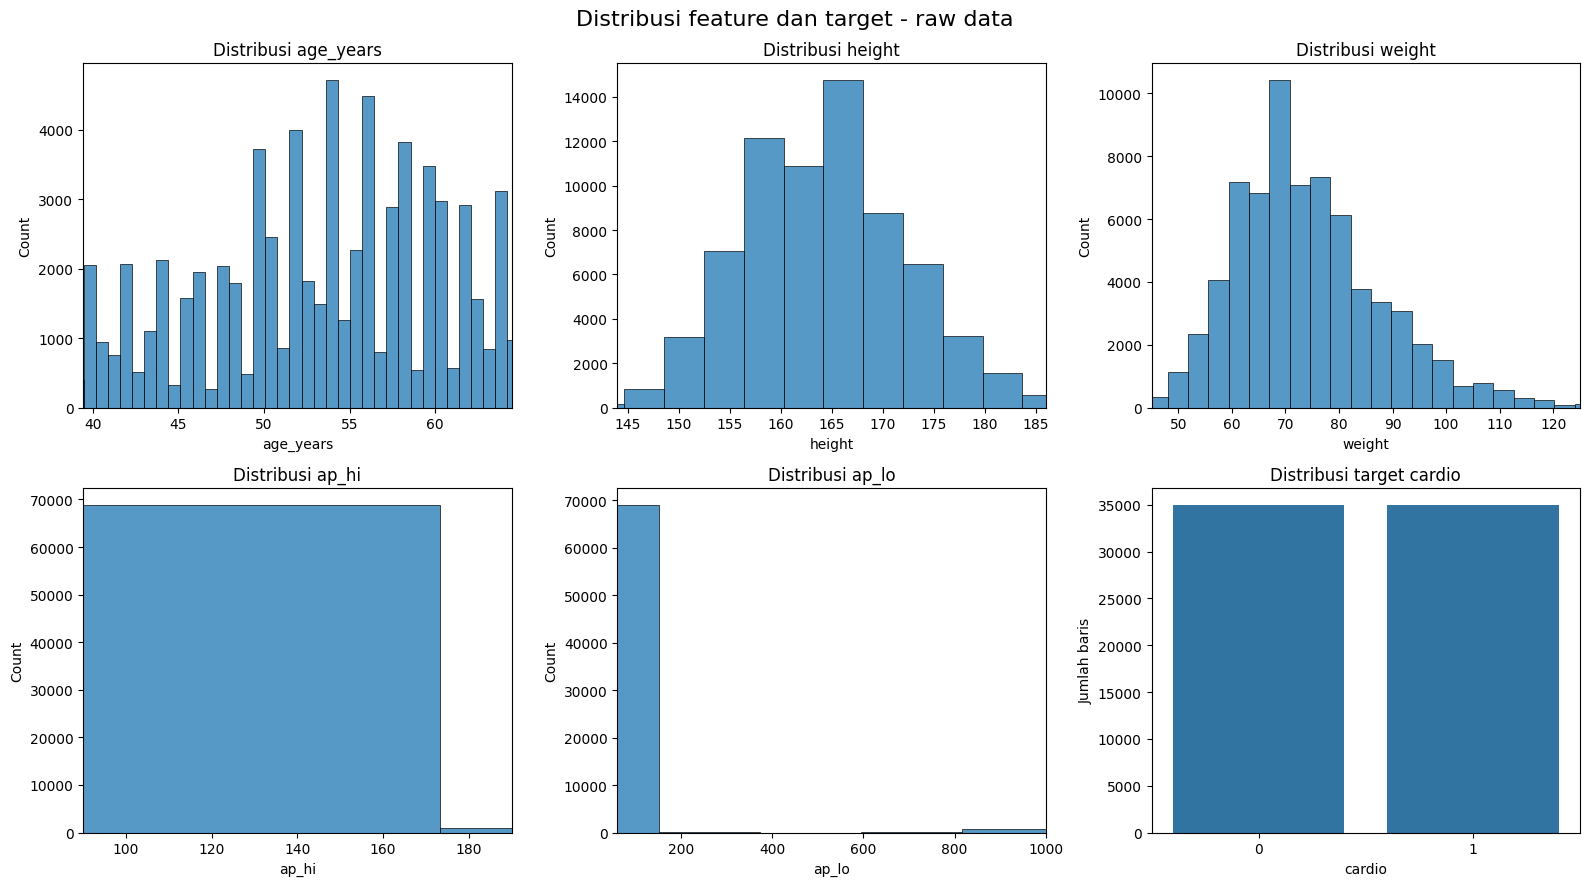

In [14]:
plot_columns = ["age_years", "height", "weight", "ap_hi", "ap_lo"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for axis, column in zip(axes, plot_columns):
    sns.histplot(data=df_eda, x=column, bins=50, ax=axis)
    axis.set_title(f"Distribusi {column}")
    axis.set_xlabel(column)

    lower_view = df_eda[column].quantile(0.005)
    upper_view = df_eda[column].quantile(0.995)
    axis.set_xlim(lower_view, upper_view)

sns.countplot(data=df, x="cardio", ax=axes[5])
axes[5].set_title("Distribusi target cardio")
axes[5].set_xlabel("cardio")
axes[5].set_ylabel("Jumlah baris")

fig.suptitle("Distribusi feature dan target - raw data", fontsize=16)
fig.tight_layout()
figure_dir = ROOT / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(
    figure_dir / "distribusi_fitur_target.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [30]:
invalid_bp_mask = (df["ap_hi"] <= 0) | (df["ap_lo"] <= 0) | (df["ap_hi"] < df["ap_lo"])

print("Baris tekanan darah:", int(invalid_bp_mask.sum()))

df_clean = df.loc[~invalid_bp_mask].copy()

df_clean["age_years"] = df_clean["age"] / 365.25
df_clean["bmi"] = df_clean["weight"] / (df_clean["height"] / 100) ** 2

df_clean = df_clean.drop(columns=["id", "age"])

print(f"Ukuran Sebelum:{df.shape}")
print(f"Ukuran Sesudah:{df_clean.shape}")
print(f"Kolom hasil:{df_clean.columns.tolist()}")
display(df_clean[["age_years", "height", "weight", "bmi"]].describe())
display(df_clean["cardio"].value_counts(normalize=True).sort_index())

Baris tekanan darah: 1256
Ukuran Sebelum:(70000, 13)
Ukuran Sesudah:(68744, 13)
Kolom hasil:['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi']


,age_years,height,weight,bmi
count,68744.000000,68744.000000,68744.000000,68744.000000
mean,53.289963,164.359857,74.116847,27.522699
std,6.757593,8.190841,14.331747,6.068215
min,29.563313,55.000000,11.000000,3.471784
25%,48.342231,159.000000,65.000000,23.875115
50%,53.938398,165.000000,72.000000,26.346494
75%,58.381930,170.000000,82.000000,30.119376
max,64.922656,250.000000,200.000000,298.666667


cardio
0    0.505179
1    0.494821
Name: proportion, dtype: float64

In [31]:
review_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

display(df_clean[review_cols].describe(percentiles=[0.999]).T[["min", "99.9%", "max"]])

extreme_cols = ["ap_hi", "ap_lo", "height", "weight"]

for column in extreme_cols:
    print(f"\nNilai Terkecil - {column}")
    display(df_clean.nsmallest(10, column)[extreme_cols])

    print(f"\nNilai Terbesar - {column}")
    display(df_clean.nlargest(10, column)[extreme_cols])

,min,99.9%,max
age_years,29.563313,64.682428,64.922656
height,55.000000,190.000000,250.000000
weight,11.000000,149.257000,200.000000
ap_hi,16.000000,210.000000,16020.000000
ap_lo,1.000000,120.000000,182.000000



Nilai Terkecil - ap_hi


,ap_hi,ap_lo,height,weight
26513,16,10,157,69.0
52851,24,20,164,64.0
13755,60,40,157,73.0
7076,70,50,154,61.0
11951,70,40,160,52.0
16629,70,50,162,57.0
45951,70,40,158,47.0
56927,70,15,155,76.0
209,80,70,172,62.0
383,80,50,147,41.0



Nilai Terbesar - ap_hi


,ap_hi,ap_lo,height,weight
40852,16020,80,169,70.0
25464,14020,80,169,75.0
25519,14020,80,169,71.0
46912,14020,90,180,78.0
47253,14020,90,160,65.0
55459,13010,80,152,76.0
55847,13010,80,161,105.0
7763,11500,90,175,80.0
51438,11020,80,168,65.0
69370,2000,100,170,74.0


...

,ap_hi,ap_lo,height,weight
6486,140,100,250,86.0
21628,100,70,207,78.0
1117,120,80,198,68.0
3237,110,70,198,61.0
8897,160,100,198,79.0
12007,110,70,198,102.0
29145,130,90,198,90.0
30127,110,90,198,85.0
30238,120,80,198,89.0
39351,120,80,198,92.0



Nilai Terkecil - weight


,ap_hi,ap_lo,height,weight
33817,130,90,178,11.0
60188,120,80,162,21.0
29488,120,80,177,22.0
26806,110,80,157,23.0
34276,120,80,128,28.0
60699,110,70,171,29.0
3752,110,70,120,30.0
18559,120,80,160,30.0
41905,103,61,143,30.0
16906,150,90,170,31.0



Nilai Terbesar - weight


,ap_hi,ap_lo,height,weight
435,130,70,186,200.0
50413,150,90,180,200.0
61285,110,80,180,183.0
4743,140,90,176,180.0
45378,140,80,190,180.0
60592,140,100,180,180.0
61362,130,80,196,180.0
20092,120,80,165,178.0
27384,140,90,80,178.0
61788,120,80,165,178.0


In [32]:
candidate_bounds = {
    "ap_hi": (70, 250),
    "ap_lo": (40, 150),
    "height": (120, 220),
    "weight": (30, 250),
}

df_review = df.loc[~invalid_bp_mask].copy()

candidate_flags = pd.DataFrame(
    {
        column: ~df_review[column].between(lower, upper, inclusive="both")
        for column, (lower, upper) in candidate_bounds.items()
    },
    index=df_review.index,
)

candidate_summary = pd.DataFrame(
    {
        "rows_flagged": candidate_flags.sum(),
        "percent_flagged": candidate_flags.mean() * 100,
    }
)
display(candidate_summary)

any_candidate_flag = candidate_flags.any(axis=1)
print(f"Baris yang ditandai:{int(any_candidate_flag.sum())}")

review_columns = ["id", "age", "height", "weight", "ap_hi", "ap_lo", "cardio"]
display(df_review.loc[any_candidate_flag, review_columns].head(25))

,rows_flagged,percent_flagged
ap_hi,36,0.052368
ap_lo,42,0.061096
height,51,0.074188
weight,6,0.008728


Baris yang ditandai:132


,id,age,height,weight,ap_hi,ap_lo,cardio
224,309,21800,76,55.0,120,80,0
418,594,16658,157,72.0,150,30,1
1876,2654,15116,160,60.0,902,60,0
3420,4838,14516,100,70.0,100,70,0
4781,6769,18961,158,74.0,200,170,1
4817,6822,14425,168,63.0,909,60,0
4981,7054,22722,173,74.0,220,160,1
5333,7590,20984,164,102.0,120,30,0
6486,9223,21220,250,86.0,140,100,1
6737,9610,16705,156,61.0,150,10,1


In [33]:
baseline = df_clean.copy()
candidate_filtered = df_clean.loc[~any_candidate_flag].copy()

variants = {"baseline": baseline, "candidate_filtered": candidate_filtered}

for name, data in variants.items():
    print(f"\n{name}: {data.shape[0]:,} baris")
    print("Proporsi Target:")
    display(data["cardio"].value_counts(normalize=True).sort_index())

    print("Ringkasan Feature:")
    display(
        data[["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]]
        .describe()
        .loc[["min", "50%", "max"]]
    )


baseline: 68,744 baris
Proporsi Target:


cardio
0    0.505179
1    0.494821
Name: proportion, dtype: float64

Ringkasan Feature:


,age_years,height,weight,ap_hi,ap_lo,bmi
min,29.563313,55.0,11.0,16.0,1.0,3.471784
50%,53.938398,165.0,72.0,120.0,80.0,26.346494
max,64.922656,250.0,200.0,16020.0,182.0,298.666667



candidate_filtered: 68,612 baris
Proporsi Target:


cardio
0    0.505305
1    0.494695
Name: proportion, dtype: float64

Ringkasan Feature:


,age_years,height,weight,ap_hi,ap_lo,bmi
min,29.563313,120.0,30.0,70.0,40.0,10.726644
50%,53.941136,165.0,72.0,120.0,80.0,26.346494
max,64.922656,207.0,200.0,240.0,150.0,108.169847


In [ ]:
bmi_review_columns = ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]

highest_bmi = candidate_filtered.nlargest(10, "bmi")
lowest_bmi = candidate_filtered.nsmallest(10, "bmi")

highest_bmi = highest_bmi.join(df["id"].rename("source_id"))
lowest_bmi = lowest_bmi.join(df["id"].rename("source_id"))

display(highest_bmi[["source_id", *bmi_review_columns]])
display(lowest_bmi[["source_id", *bmi_review_columns]])

,source_id,age_years,height,weight,bmi,ap_hi,ap_lo
6153,8757,57.467488,122,161.0,108.169847,120,80
15366,21958,47.652293,125,167.0,106.880000,180,90
12435,17757,60.443532,137,161.0,85.779743,150,100
67866,96921,59.583847,133,123.0,69.534739,180,100
40712,58175,59.488022,154,162.0,68.308315,120,80
18952,27063,42.220397,155,163.0,67.845994,180,100
20092,28683,56.553046,165,178.0,65.381084,120,80
61788,88220,51.898700,165,178.0,65.381084,120,80
63687,90930,64.292950,154,155.0,65.356721,170,80
2458,3470,64.739220,159,165.0,65.266406,130,70


,source_id,age_years,height,weight,bmi,ap_hi,ap_lo
16906,24167,47.288159,170,31.0,10.726644,150,90
18559,26503,49.664613,160,30.0,11.718750,120,80
58200,83048,61.722108,169,35.0,12.254473,140,90
16322,23318,59.882272,165,35.0,12.855831,100,70
38417,54851,59.709788,154,32.0,13.493001,110,60
9487,13518,57.379877,172,40.0,13.520822,140,90
10447,14908,60.251882,162,38.0,14.479500,100,70
33511,47872,57.716632,153,34.0,14.524328,110,70
32608,46562,52.038330,176,45.0,14.527376,120,79
16225,23181,53.719370,196,56.0,14.577259,125,80


In [10]:
import os
from pathlib import Path
from dotenv import load_dotenv

cwd = Path.cwd().resolve()
project_root = next(
    (
        path
        for path in (cwd, *cwd.parents)
        if (path / "README.md").is_file() and (path / "notebooks").is_dir()
    ),
    cwd,
)

dotenv_path = project_root / ".env"
print(".env ditemukan:", dotenv_path.is_file())

load_dotenv(dotenv_path, override=True)

for key in (
    "MLFLOW_TRACKING_URI",
    "MLFLOW_TRACKING_USERNAME",
    "MLFLOW_TRACKING_PASSWORD",
):
    print(f"{key}: {'OK' if os.getenv(key) else 'MISSING'}")

.env ditemukan: True
MLFLOW_TRACKING_URI: OK
MLFLOW_TRACKING_USERNAME: OK
MLFLOW_TRACKING_PASSWORD: OK


In [11]:
import mlflow

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("cardiovascular-disease-baseline")

with mlflow.start_run(run_name="tracking-smoke-test"):
    mlflow.log_param("purpose", "verify_dagshub_tracking")
    mlflow.log_metric("connection_test", 1.0)

print("Smoke test berhasil dikirim.")

2026/10/07 10:21:10 INFO mlflow.tracking.fluent: Experiment with name 'cardiovascular-disease-baseline' does not exist. Creating a new experiment.


🏃 View run tracking-smoke-test at: https://dagshub.com/aldihimawan88/cardiovascular-disease-mlops.mlflow/#/experiments/0/runs/9edde536bf034a5e8e683bc55dbaa3e4
🧪 View experiment at: https://dagshub.com/aldihimawan88/cardiovascular-disease-mlops.mlflow/#/experiments/0
Smoke test berhasil dikirim.
